## Postlab

## CNN

C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9302 - loss: 0.2224 - val_accuracy: 0.9870 - val_loss: 0.0443
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.9775 - loss: 0.0760 - val_accuracy: 0.9893 - val_loss: 0.0379
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9827 - loss: 0.0579 - val_accuracy: 0.9912 - val_loss: 0.0311
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9912 - val_loss: 0.0315
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9888 - loss: 0.0375 - val_accuracy: 0.9920 - val_loss: 0.0298
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9910 - loss: 0.0256
CNN Test Accuracy: 99.09999966621399 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
Actual: 7
Predicted: 7
Actual: 2
Predicted: 2
Actual: 1
Predicted: 1
Actual: 0
Predicted: 0
Actual: 4
Predicted: 4


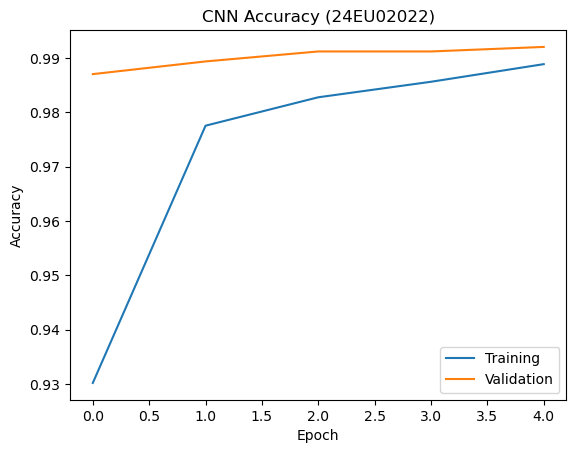

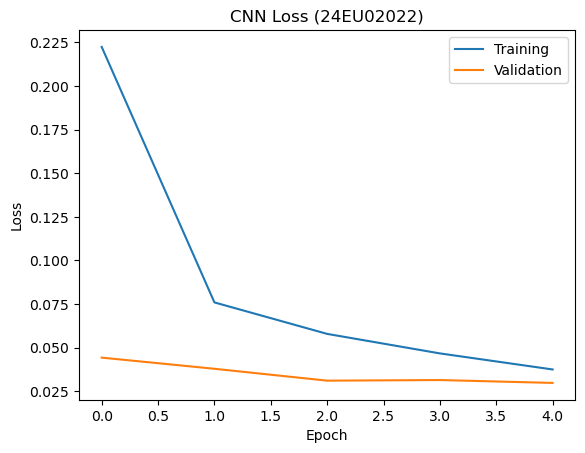

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

# CNN model
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Compile
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
cnn.summary()

# Train
history = cnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# Test
loss, accuracy = cnn.evaluate(X_test, y_test)

print("CNN Test Accuracy:", accuracy * 100, "%")

# Prediction
pred = cnn.predict(X_test[:5])

for i in range(5):
    print("Actual:", y_test[i])
    print("Predicted:", pred[i].argmax())

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (24EU02022)")
plt.legend(["Training", "Validation"])
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (24EU02022)")
plt.legend(["Training", "Validation"])
plt.show()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data shape: 25000
Testing data shape: 25000
X_train shape: (25000, 200)
X_test shape: (25000, 200)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.5338 - loss: 0.6904 - val_accuracy: 0.5120 - val_loss: 0.6917
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.6021 - loss: 0.6507 - val_accuracy: 0.6228 - val_loss: 0.6525
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.6430 - loss: 0.5943 - val_accuracy: 0.6218 - val_loss: 0.6092
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.6557 - loss: 0.5650 - val_accuracy: 0.6478 - val_loss: 0.6130
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.8028 - loss: 0.4285 - val_accuracy: 0.8272 - val_loss: 0.4226

RNN Test Accuracy: 81.84800148010254 %

Predictions:
Actual: Negative
Predicted: Negative

Actual: Positive
Predicted: Positive

Actual: Positive
Predicted: Positive

Actual: Negative
Predicted: Negative

Actual: Positive
Predicted: Positive



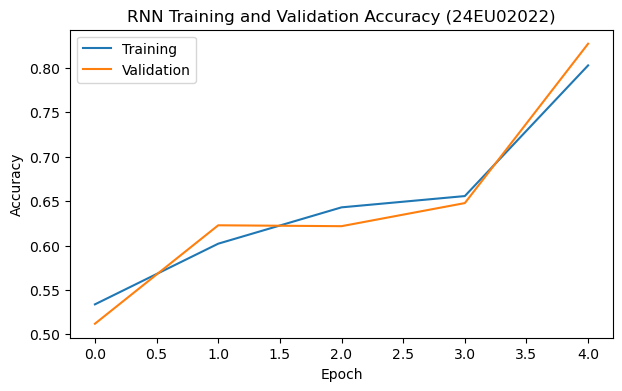

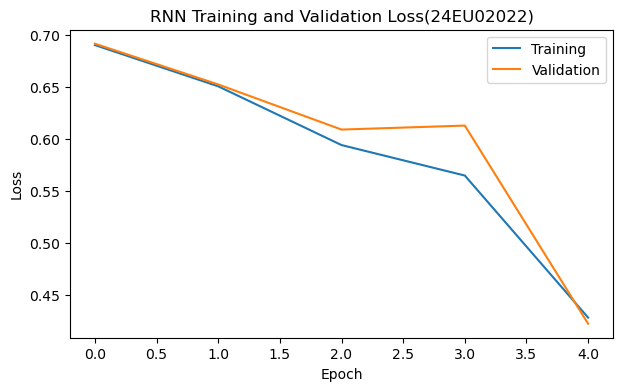

In [2]:

import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
vocab_size = 10000
max_length = 200

# Load IMDB dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training data shape:", len(X_train))
print("Testing data shape:", len(X_test))

# Pad sequences
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Create RNN model
rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

# Compile model
rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model
rnn.summary()

# Train model
history = rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate model
loss, accuracy = rnn.evaluate(X_test, y_test, verbose=0)

print("\nRNN Test Accuracy:", accuracy * 100, "%")

# Prediction
pred = rnn.predict(X_test[:5], verbose=0)

print("\nPredictions:")

for i in range(5):

    actual = "Positive" if y_test[i] == 1 else "Negative"
    predicted = "Positive" if pred[i][0] >= 0.5 else "Negative"

    print("Actual:", actual)
    print("Predicted:", predicted)
    print()

# Accuracy graph
plt.figure(figsize=(7, 4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy (24EU02022)")
plt.legend(["Training", "Validation"])
plt.show()

# Loss graph
plt.figure(figsize=(7, 4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training and Validation Loss(24EU02022)")
plt.legend(["Training", "Validation"])
plt.show()